### The data set has information about features of silhouette extracted from the images of different cars

Four "Corgie" model vehicles were used for the experiment: a double decker bus, Cheverolet van, Saab 9000 and an Opel Manta 400 cars. This particular combination of vehicles was chosen with the expectation that the bus, van and either one of the cars would be readily distinguishable, but it would be more difficult to distinguish between the cars.



In [1]:
# Numerical libraries
import numpy as np   
from sklearn.cluster import KMeans
import pandas as pd    
import matplotlib.pyplot as plt   
import seaborn as sns

### 1. Read the dataset using function .dropna() - to avoid dealing with NAs as of now

In [2]:
# Read data
df = pd.read_csv("vehicle.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

In [3]:
# Missing value counts
df.isna().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

In [4]:
# Drop missing values
df.dropna(inplace=True)
df.isna().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

In [5]:
# Final dataframe shape
df.shape

(813, 19)

### 2. Print/ Plot the dependent (categorical variable) - Class column

Since the variable is categorical, you can use value_counts function

In [6]:
print('Dependent variable distribution:')
df['class'].value_counts()

Dependent variable distribution:


car    413
bus    205
van    195
Name: class, dtype: int64

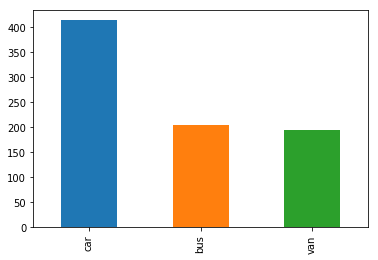

In [7]:
# Plot distribution
values = df['class'].value_counts()
values.plot(kind='bar')

### Check for any missing values in the data 

In [8]:
# Check missing values
df.isna().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

### 3. Standardize the data 

In [9]:
# Describe data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness,813.0,93.656827,8.233751,73.0,87.0,93.0,100.0,119.0
circularity,813.0,44.803198,6.146659,33.0,40.0,44.0,49.0,59.0
distance_circularity,813.0,82.043050,15.783070,40.0,70.0,79.0,98.0,112.0
radius_ratio,813.0,169.098401,33.615402,104.0,141.0,167.0,195.0,333.0
pr.axis_aspect_ratio,813.0,61.774908,7.973000,47.0,57.0,61.0,65.0,138.0
max.length_aspect_ratio,813.0,8.599016,4.677174,2.0,7.0,8.0,10.0,55.0
scatter_ratio,813.0,168.563346,33.082186,112.0,146.0,157.0,198.0,265.0
elongatedness,813.0,40.988930,7.803380,26.0,33.0,43.0,46.0,61.0
pr.axis_rectangularity,813.0,20.558426,2.573184,17.0,19.0,20.0,23.0,29.0
max.length_rectangularity,813.0,147.891759,14.504648,118.0,137.0,146.0,159.0,188.0


Since the dimensions of the data are not really known to us, it would be wise to standardize the data using z scores before we go for any clustering methods.
You can use zscore function to do this

In [10]:
# Using zscore to standardize the data
from scipy.stats import zscore
df_attr = df.drop(['class'], axis=1)
df_attr_z = df_attr.apply(zscore)
df_attr_z.head()
classes  = df.pop("class")
df_withClass = df_attr_z.join(classes)   # Recreating mpg_df by combining numerical columns with car names
df_withClass.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,0.163231,0.520408,0.060669,0.264970,1.283254,0.299721,-0.198517,0.129648,-0.217151,0.766312,-0.397397,-0.339014,0.301676,-0.321192,-0.071523,0.371287,-0.321809,0.171837,van
1,-0.322874,-0.619123,0.124067,-0.836393,-0.599253,0.085785,-0.591720,0.514333,-0.606014,-0.337462,-0.590034,-0.618754,-0.502972,-0.053505,0.538425,0.147109,0.003400,0.442318,van
2,1.256966,0.845988,1.518823,1.187734,0.530251,0.299721,1.162569,-1.152637,0.949438,0.697326,1.111591,1.122486,1.415804,0.080339,1.555006,-0.413338,-0.159204,0.036596,car
3,-0.079822,-0.619123,-0.002729,-0.300595,0.153750,0.085785,-0.742952,0.642562,-0.606014,-0.337462,-0.911095,-0.738643,-1.462359,-1.258099,-0.071523,-0.301249,1.629444,1.524243,van
4,-1.052030,-0.130753,-0.763506,1.068668,5.173770,9.285029,-0.591720,0.514333,-0.606014,-0.268476,1.689501,-0.647299,0.425468,7.307905,0.538425,-0.189159,-1.460039,-1.721531,bus


In [11]:
# Describe data
df_attr_z.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness,813.0,-2.425284e-16,1.000616,-2.510344,-0.808978,-0.079822,0.770861,3.079857
circularity,813.0,-4.642999e-16,1.000616,-1.921444,-0.781913,-0.130753,0.683198,2.311100
distance_circularity,813.0,-2.351542e-16,1.000616,-2.665447,-0.763506,-0.192923,1.011639,1.899212
radius_ratio,813.0,3.665238e-16,1.000616,-1.937757,-0.836393,-0.062462,0.771002,4.878790
pr.axis_aspect_ratio,813.0,-2.047016e-16,1.000616,-1.854258,-0.599253,-0.097251,0.404751,9.566288
max.length_aspect_ratio,813.0,-1.349201e-16,1.000616,-1.411767,-0.342087,-0.128151,0.299721,9.926837
scatter_ratio,813.0,3.714399e-16,1.000616,-1.710835,-0.682459,-0.349749,0.890352,2.916857
elongatedness,813.0,-2.062038e-16,1.000616,-1.922008,-1.024408,0.257876,0.642562,2.565989
pr.axis_rectangularity,813.0,-2.651972e-16,1.000616,-1.383740,-0.606014,-0.217151,0.949438,3.282615
max.length_rectangularity,813.0,-7.398756e-16,1.000616,-2.062109,-0.751377,-0.130505,0.766312,2.766901


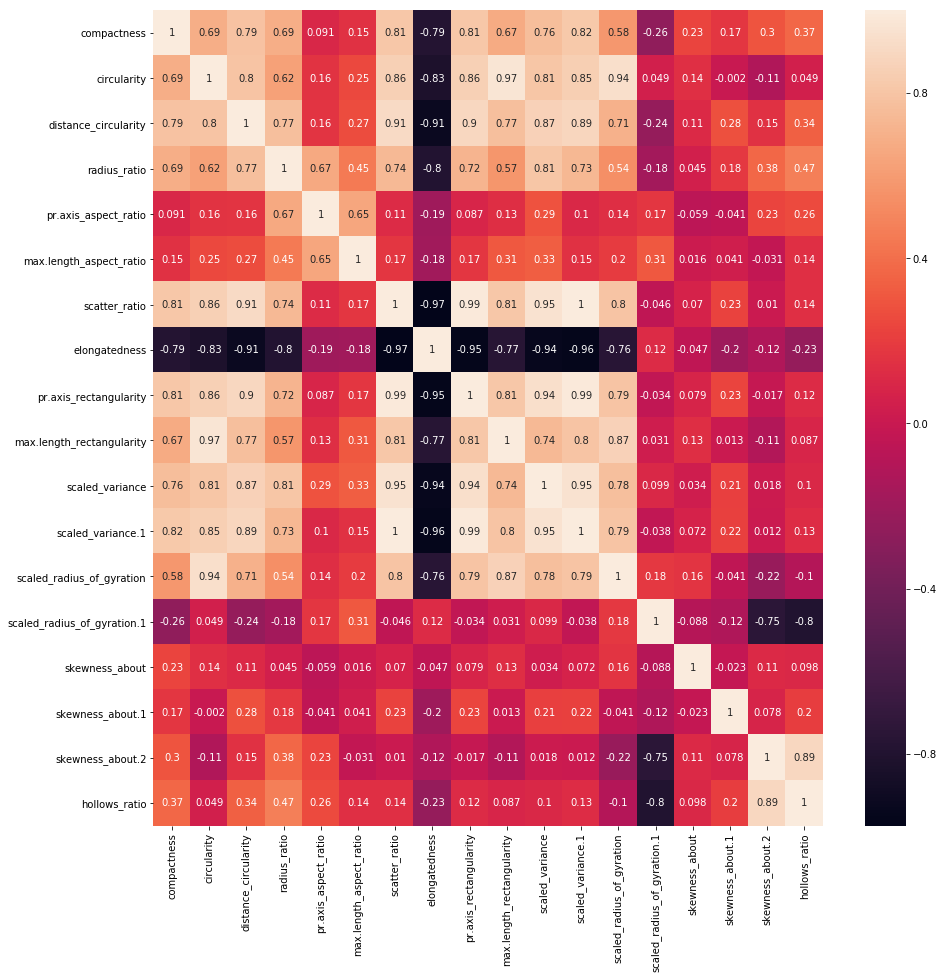

In [12]:
## Variation of same features seem to exist, check correlation to ensure they are independent
corr = df_attr_z.corr()
plt.figure(figsize=(15,15)) 
sns.heatmap(corr, annot=True)

### NOTE: Droping scaled_variance as it is highly correlated with scaled_variance.1 as well as shows similar relations as scaled_variance.1 with other variables

In [13]:
df_attr_z = df_attr_z.drop(['scaled_variance'], axis=1)

### K - Means Clustering

### 4. Assign a dummy array called distortion

In [14]:
# Assigning a dummy array (empty for now)
distortion = []
distortion = np.array(distortion)

In [15]:
# Validate type
type(distortion)

numpy.ndarray

You can later use this array to plot the elbow plot

### 5. Calculating distortion - C distance

Iterating values of k from 1 to 10 fit K means model
Using c distance - Get the measure for Sum of squares error.

In [16]:
#Finding optimal no. of clusters
from scipy.spatial.distance import cdist
clusters=range(1,10)
SSE=[]

for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(df_attr_z)
    prediction=model.predict(df_attr_z)
    SSE.append(sum(np.min(cdist(df_attr_z, model.cluster_centers_, 'euclidean'), axis=1)))# / df_attr_z.shape[0])

In [17]:
SSE

[3116.6527566068225,
 2380.75264997424,
 2115.5869653565546,
 2039.709191748445,
 1941.9154129381911,
 1853.400733970263,
 1800.8437718962132,
 1742.005645582129,
 1696.9283756391076]

### 6. Plotting Elbow/ Scree Plot

Use Matplotlib to plot the scree plot - Note: Scree plot plots distortion vs the no of clusters

Text(0.5,1,'Selecting k with the Elbow Method')

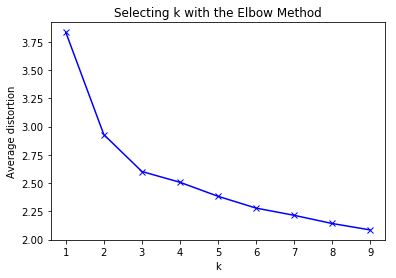

In [18]:
#Finding optimal no. of clusters
from scipy.spatial.distance import cdist
clusters=range(1,10)
meanDistortions=[]

for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(df_attr_z)
    prediction=model.predict(df_attr_z)
    meanDistortions.append(sum(np.min(cdist(df_attr_z, model.cluster_centers_, 'euclidean'), axis=1)) / df_attr_z.shape[0])
    
plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')

### Find out the optimal value of K

In [19]:
# K = 3 as the best bend happens at that point
final_model = KMeans(3)
final_model.fit(df_attr_z)
prediction = final_model.predict(df_attr_z)

#Append the prediction 
df_withClass["CLUSTER"] = prediction
#print("Clusters Assigned : \n")
#df_withClass[["class", "CLUSTER"]]

In [20]:
print("Clusters Assigned for various class categories : \n")
df_withClass.pivot_table(index=['class'], columns='CLUSTER', aggfunc='size', fill_value=0)

Clusters Assigned for various class categories : 



CLUSTER,0,1,2
class,,,
bus,44,86,75
car,212,77,124
van,4,94,97


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000028AD5E7BF60>,
      dtype=object)

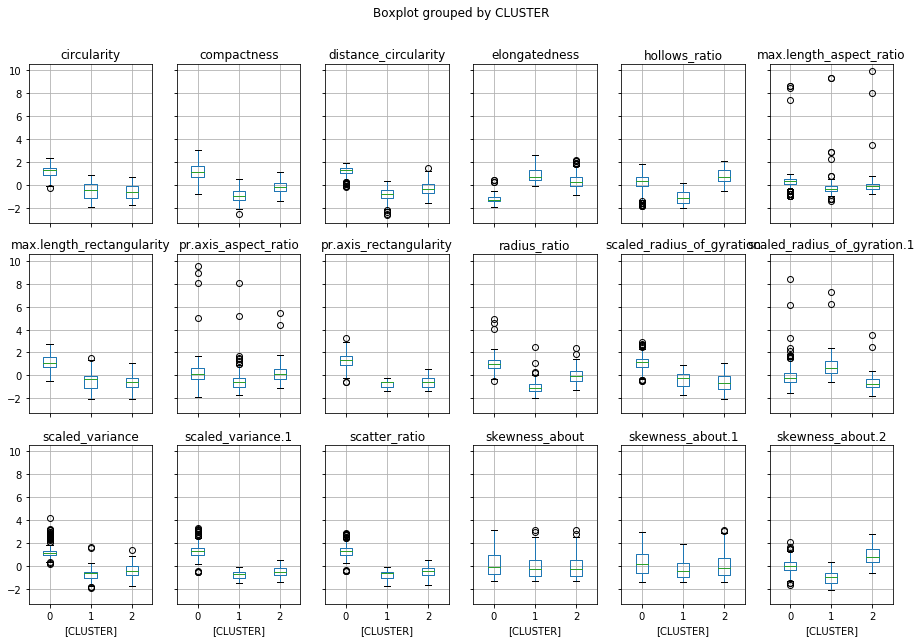

In [21]:
df_withClass.boxplot(by = 'CLUSTER',  layout=(3,6), figsize=(15, 10))

### Using optimal value of K - Cluster the data. 
Note: Since the data has more than 2 dimension we cannot visualize the data. As an alternative, we can observe the centroids and note how they are distributed across different dimensions

You can use kmeans.cluster_centers_ function to pull the centroid information from the instance

In [22]:
centroids = final_model.cluster_centers_

In [23]:
centroids

array([[ 1.13076532,  1.17094237,  1.19500584,  1.01909505,  0.21505188,
         0.34250798,  1.27180461, -1.19061224,  1.27548416,  1.09266768,
         1.28132727,  1.07954232, -0.02879497,  0.16229031,  0.26566456,
        -0.00535553,  0.18380067],
       [-0.88936507, -0.48230345, -0.83973136, -1.01429787, -0.46007964,
        -0.20556753, -0.75213153,  0.82467633, -0.72252138, -0.44510158,
        -0.76016801, -0.35629973,  0.78601377, -0.08813666, -0.30822691,
        -1.01525002, -1.05637916],
       [-0.2210546 , -0.60977375, -0.32057621, -0.01449378,  0.21056412,
        -0.12236898, -0.46409256,  0.3297884 , -0.4930334 , -0.57331922,
        -0.46547943, -0.6388918 , -0.65715827, -0.06602824,  0.03426193,
         0.88618815,  0.75574753]])

### 7. Store the centroids in a dataframe with column names from the original dataset given 

Hint: Use pd.Dataframe function 

In [24]:
centroids_df = pd.DataFrame(centroids, columns=['compactness', 'circularity', 'distance_circularity', 'radius_ratio', 
                                                'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio', 
                                                'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity'
                                                , 'scaled_variance.1', 'scaled_radius_of_gyration', 
                                                'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1', 
                                                'skewness_about.2', 'hollows_ratio' ])

In [25]:
centroids_df.T

,0,1,2
compactness,1.130765,-0.889365,-0.221055
circularity,1.170942,-0.482303,-0.609774
distance_circularity,1.195006,-0.839731,-0.320576
radius_ratio,1.019095,-1.014298,-0.014494
pr.axis_aspect_ratio,0.215052,-0.460080,0.210564
max.length_aspect_ratio,0.342508,-0.205568,-0.122369
scatter_ratio,1.271805,-0.752132,-0.464093
elongatedness,-1.190612,0.824676,0.329788
pr.axis_rectangularity,1.275484,-0.722521,-0.493033
max.length_rectangularity,1.092668,-0.445102,-0.573319


### Use kmeans.labels_ function to print out the labels of the classes

In [26]:
final_model.labels_

array([2, 2, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 0, 1, 1, 2, 2, 0,
       2, 1, 0, 0, 1, 2, 2, 2, 0, 2, 1, 0, 0, 1, 0, 1, 1, 2, 0, 1, 1, 1,
       1, 2, 1, 2, 0, 2, 0, 2, 2, 1, 0, 1, 0, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 1, 2, 0, 2, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 1, 0, 2, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 2, 2, 1, 0, 0, 1, 1, 0, 2, 2, 1, 1, 1, 2, 0, 0, 2,
       1, 1, 2, 1, 1, 1, 1, 1, 2, 0, 0, 2, 2, 1, 0, 0, 1, 2, 1, 2, 2, 0,
       1, 2, 0, 2, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 1, 2, 1, 0, 2, 2, 0, 0,
       2, 0, 1, 1, 0, 0, 2, 0, 1, 2, 2, 2, 1, 0, 1, 2, 1, 0, 2, 2, 2, 0,
       2, 0, 2, 0, 2, 1, 0, 1, 1, 1, 1, 2, 0, 0, 2, 2, 2, 1, 0, 2, 2, 2,
       0, 1, 1, 0, 1, 2, 0, 1, 1, 1, 2, 0, 2, 0, 1, 1, 1, 1, 0, 2, 1, 2,
       0, 1, 2, 2, 1, 0, 1, 1, 2, 2, 0, 1, 0, 1, 2, 1, 0, 2, 2, 0, 0, 1,
       2, 2, 2, 0, 1, 2, 2, 1, 1, 2, 2, 0, 2, 1, 1, 0, 2, 2, 1, 1, 0, 1,
       2, 0, 1, 2, 0, 1, 2, 0, 2, 0, 1, 2, 2, 0, 2, 2, 2, 1, 2, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 2, 1, 0, 0, 1, 0, 2, 1,

## Hierarchical Clustering 

### 8. Variable creation

For Hierarchical clustering, we will create datasets using multivariate normal distribution to visually observe how the clusters are formed at the end

In [27]:
a = np.random.multivariate_normal([10, 0], [[3, 1], [1, 4]], size=[100,])
b = np.random.multivariate_normal([0, 20], [[3, 1], [1, 4]], size=[50,])
c = np.random.multivariate_normal([10, 20], [[3, 1], [1, 4]], size=[100,])

In [28]:
a.shape

(100, 2)

In [29]:
b.shape

(50, 2)

In [30]:
c.shape

(100, 2)

### 9. Combine all three arrays a,b,c into a dataframe

In [31]:
d = np.concatenate([a, b,c])
d = pd.DataFrame(d)

In [32]:
d.shape

(250, 2)

### 10. Use scatter matrix to print all the 3 distributions

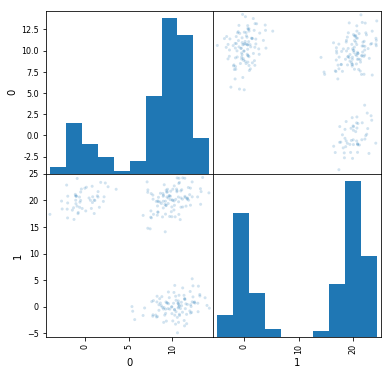

In [33]:
from pandas.plotting import scatter_matrix

axs = scatter_matrix(d, alpha=0.2, figsize=(6,6))#, diagonal='kde')

### 11. Find out the linkage matrix

Use ward as linkage metric and distance as Eucledian

In [34]:
# Calculate the linkage_matrix
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import linkage, dendrogram
linkage_matrix = linkage(d,method='ward')

In [35]:
linkage_matrix

array([[2.70000000e+01, 3.10000000e+01, 4.15679472e-02, 2.00000000e+00],
       [1.14000000e+02, 1.48000000e+02, 4.59757914e-02, 2.00000000e+00],
       [1.20000000e+01, 9.40000000e+01, 5.29467019e-02, 2.00000000e+00],
       [1.94000000e+02, 2.37000000e+02, 5.44865496e-02, 2.00000000e+00],
       [1.76000000e+02, 1.87000000e+02, 5.87860238e-02, 2.00000000e+00],
       [3.00000000e+00, 8.10000000e+01, 6.11013234e-02, 2.00000000e+00],
       [2.50000000e+01, 6.20000000e+01, 7.88802221e-02, 2.00000000e+00],
       [1.59000000e+02, 2.43000000e+02, 8.37809904e-02, 2.00000000e+00],
       [1.97000000e+02, 2.06000000e+02, 8.97800957e-02, 2.00000000e+00],
       [2.10000000e+01, 2.30000000e+01, 9.23295956e-02, 2.00000000e+00],
       [1.65000000e+02, 1.75000000e+02, 1.06731871e-01, 2.00000000e+00],
       [1.18000000e+02, 1.47000000e+02, 1.16947314e-01, 2.00000000e+00],
       [1.93000000e+02, 2.00000000e+02, 1.27800670e-01, 2.00000000e+00],
       [2.20000000e+01, 5.50000000e+01, 1.36027554e

### 12. Plot the dendrogram for the consolidated dataframe

In [36]:
# Check on cophenet value
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

c, coph_dists = cophenet(linkage_matrix, pdist(d))
c

0.9595157586403018

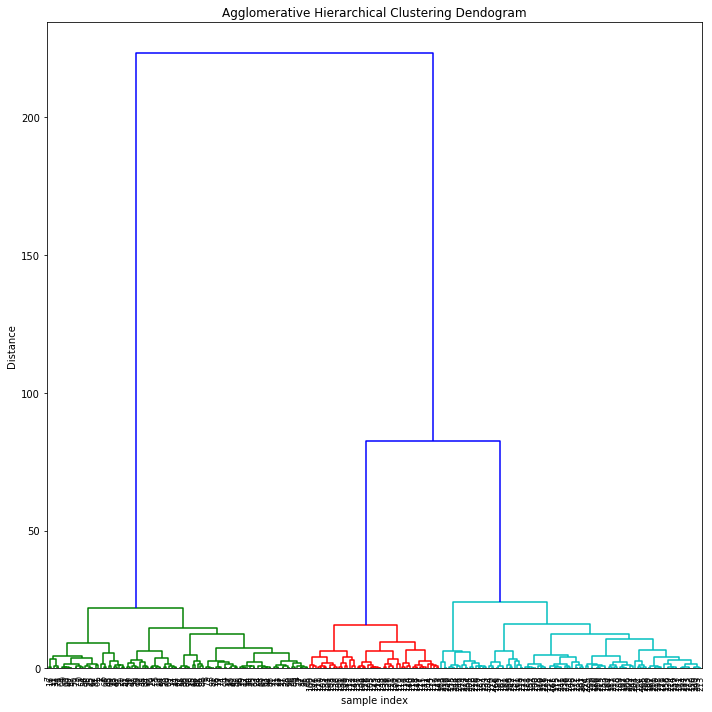

In [37]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(linkage_matrix, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

### 13. Recreate the dendrogram for last 12 merged clusters 

Hint: Use truncate_mode='lastp' attribute in dendrogram function to arrive at dendrogram 

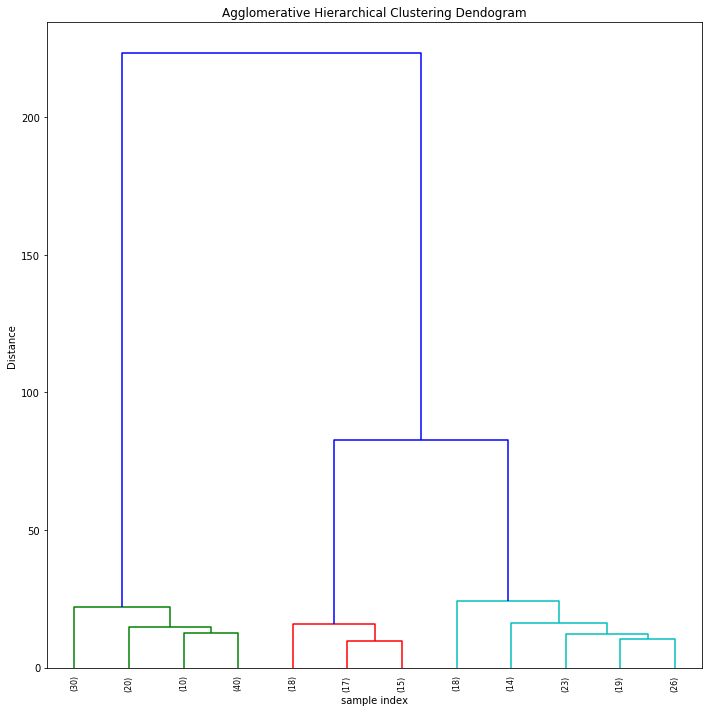

In [38]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(linkage_matrix, truncate_mode='lastp', p=12, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

### 14. From the truncated dendrogram, find out the optimal distance between clusters which u want to use an input for clustering data

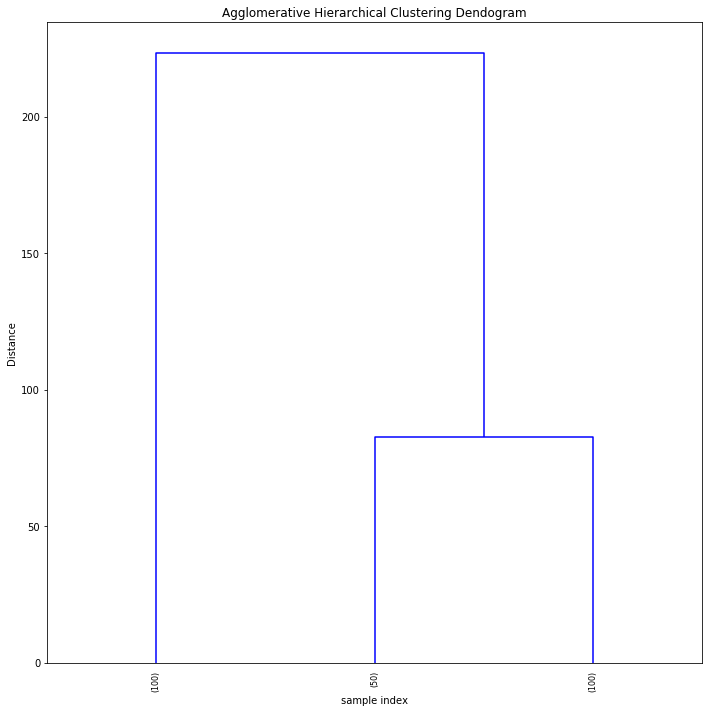

In [39]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(linkage_matrix, truncate_mode='lastp', p=3, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

### 15. Using this distance measure and fcluster function to cluster the data into 3 different groups

In [40]:
from scipy.cluster.hierarchy import fcluster
max_d = 40
clusters = fcluster(linkage_matrix, max_d, criterion='distance')
clusters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

### Use matplotlib to visually observe the clusters in 2D space 

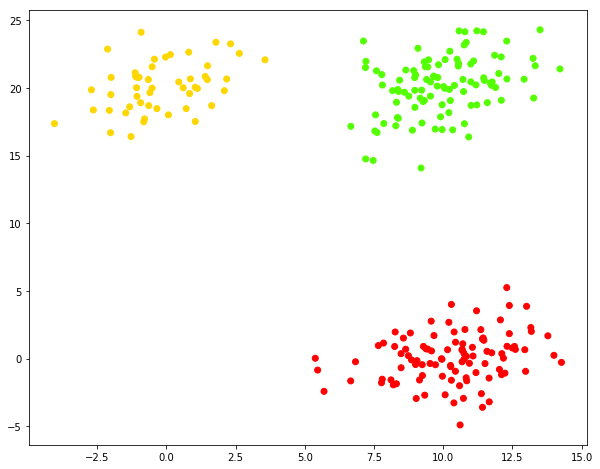

In [41]:
plt.figure(figsize=(10, 8))
plt.scatter(d.iloc[:,0], d.iloc[:,1], c=clusters, cmap='prism')  # plot points with cluster dependent colors
plt.show()